#### Librerías

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Datos

In [64]:
df=pd.read_csv("data/car_fuel_efficiency.csv")
df.columns=df.columns.str.lower().str.replace(" ","_")
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [65]:
cols=list(df.dtypes[df.dtypes=='object'].index)

for col in cols:
    df[col]=df[col].str.lower().str.replace(" ","_") #reemplazamos espacios por guiones bajos y pasamos a minusculas
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,europe,gasoline,all-wheel_drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,usa,gasoline,front-wheel_drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,europe,gasoline,front-wheel_drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,usa,diesel,all-wheel_drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,europe,gasoline,all-wheel_drive,2.0,12.488369


In [66]:
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight', 'acceleration', 'model_year', 'origin', 'fuel_type',
       'drivetrain', 'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')

In [67]:
variables=['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']
df_red=df[variables]

Como se ve a continuación, la variable de la eficiencia del combustible tiene una distribución bastante asimétrica, es decir, no tiene marcada ni cola izquierda ni cola derecha

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

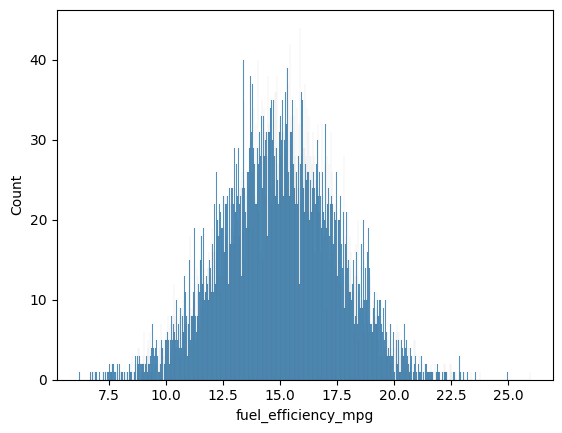

In [50]:
sns.histplot(df_red.fuel_efficiency_mpg, bins=1000)

##### Pregunta 1: hay una columna con valores nulos. ¿Cuál es?

#### Respuesta: la columna 'horsepower'

In [68]:
df_red.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

##### Pregunta 2: ¿Cuál es la mediana de la columna 'horsepower'?

##### Respuesta: $149.65729212983547$

In [52]:
df_red['horsepower'].mean()

np.float64(149.65729212983547)

##### Preparación y separación de los datos

In [69]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_val-n_test
n,n_val+n_test+n_train 

(9704, 9704)

In [54]:
idx=np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)
idx #indices aleatorios

array([ 483, 7506, 8795, ..., 5390,  860, 7270])

In [70]:
df_red_train=df_red.iloc[idx[:n_train]]
df_red_val=df_red.iloc[idx[n_train:n_train+n_val]]
df_red_test=df_red.iloc[idx[n_train+n_val:]] # uso idx para que los conjuntos de train, validation y test sean aleatorios

In [71]:
df_red_train=df_red_train.reset_index(drop=True)
df_red_val=df_red_val.reset_index(drop=True)
df_red_test=df_red_test.reset_index(drop=True)

In [72]:
y_train=df_red_train.fuel_efficiency_mpg.values # el .values sirve para haerlo como una matriz
y_val=df_red_val.fuel_efficiency_mpg.values
y_test=df_red_test.fuel_efficiency_mpg.values

In [73]:
del df_red_train['fuel_efficiency_mpg']
del df_red_val['fuel_efficiency_mpg']
del df_red_test['fuel_efficiency_mpg']

##### Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 2 decimal digits using round(score, 2)
- Which option gives better RMSE?

In [103]:
Xs=['engine_displacement','horsepower','vehicle_weight','model_year']

In [110]:
def prepare_x_mean(df,df_train):
    df_num=df[Xs].copy()
    df_num=df_num.fillna(df_train['horsepower'].mean())
    x=df_num.values
    return x

def prepare_x_zero(df):
    df_num=df[Xs].copy()
    df_num=df_num.fillna(0)
    x=df_num.values
    return x

def train_linear_regression(X,y):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])
    XTX=X.T.dot(X)
    XTX_inv=np.linalg.inv(XTX)
    w_full=XTX_inv.dot(X.T).dot(y)
    return w_full[0],w_full[1:]

def rmse(y,y_pred):
    error=y-y_pred
    se=error**2
    mse=se.mean()
    return round(np.sqrt(mse),2)

In [111]:
x_train_mean=prepare_x_mean(df_red_train,df_red_train)
w0_mean,w_mean=train_linear_regression(x_train_mean,y_train)
y_pred=w0_mean+x_train_mean.dot(w_mean)
rmse(y_train,y_pred)

np.float64(0.46)

In [109]:
x_train_zero=prepare_x_zero(df_red_train)
w0_zero,w_zero=train_linear_regression(x_train_zero,y_train)
y_pred=w0_zero+x_train_zero.dot(w_zero)
rmse(y_train,y_pred)

np.float64(0.52)